In [120]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.model_selection import KFold
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import RandomizedSearchCV

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.linear_model import LinearRegression

from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor

import joblib

In [121]:
train = pd.read_csv("../data/Cap_Training_Data_2025.csv")
test = pd.read_csv("../data/Cap_Test_Data_2025.csv")
sample = pd.read_csv("../data/Cap_Sample_Submission_2025.csv")

In [122]:
train.head()

,ID,Maker,model,Location,Distance,Owner Type,manufacture_year,Age of car,engine_displacement,engine_power,body_type,Vroom Audit Rating,transmission,door_count,seat_count,fuel_type,Price
0,11100001,skoda,octavia,Ahmedabad,NaN,Second,1973.0,52,1964,147.0,compact,8,man,NaN,NaN,petrol,543764.25
1,11100002,fiat,panda,Ahmedabad,27750.0,Third,2021.0,4,1242,51.0,NaN,6,man,4.0,4.0,petrol,401819.25
2,11100003,bmw,x1,Hyderabad,46000.0,Third,2023.0,2,1995,105.0,NaN,7,auto,4.0,5.0,diesel,2392855.50
3,11100004,nissan,juke,Mumbai,43949.0,Third,2020.0,5,1618,140.0,NaN,7,man,4.0,5.0,petrol,958606.50
4,11100005,bmw,x5,Jaipur,59524.0,Fourth & Above,2021.0,4,2993,180.0,NaN,7,auto,4.0,5.0,diesel,3085561.50


In [123]:
train.shape

(53515, 17)

In [124]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53515 entries, 0 to 53514
Data columns (total 17 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   53515 non-null  int64  
 1   Maker                53515 non-null  object 
 2   model                53515 non-null  object 
 3   Location             53509 non-null  object 
 4   Distance             52304 non-null  float64
 5   Owner Type           53515 non-null  object 
 6   manufacture_year     53513 non-null  float64
 7   Age of car           53515 non-null  int64  
 8   engine_displacement  53515 non-null  int64  
 9   engine_power         52076 non-null  float64
 10  body_type            4136 non-null   object 
 11  Vroom Audit Rating   53515 non-null  int64  
 12  transmission         53515 non-null  object 
 13  door_count           45981 non-null  float64
 14  seat_count           45004 non-null  float64
 15  fuel_type            53515 non-null 

In [125]:
train.describe()

,ID,Distance,manufacture_year,Age of car,engine_displacement,engine_power,Vroom Audit Rating,door_count,seat_count,Price
count,5.351500e+04,5.230400e+04,53513.000000,53515.000000,53515.000000,52076.000000,53515.000000,45981.000000,45004.000000,5.351500e+04
mean,1.112676e+07,9.454626e+04,2019.408032,5.591946,1904.049014,100.448345,5.998374,3.973011,4.886099,1.098084e+06
std,1.544859e+04,2.755617e+05,4.650367,4.650281,1496.564596,45.330622,1.418336,0.740659,0.564332,8.441565e+05
min,1.110000e+07,0.000000e+00,1943.000000,0.000000,14.000000,10.000000,4.000000,1.000000,1.000000,3.000000e+00
25%,1.111338e+07,1.549000e+04,2017.000000,2.000000,1395.000000,73.000000,5.000000,4.000000,5.000000,5.051812e+05
50%,1.112676e+07,6.552000e+04,2020.000000,5.000000,1896.000000,91.000000,6.000000,4.000000,5.000000,8.854552e+05
75%,1.114014e+07,1.356410e+05,2023.000000,8.000000,1995.000000,125.000000,7.000000,4.000000,5.000000,1.477829e+06
max,1.115352e+07,9.899800e+06,2025.000000,82.000000,32000.000000,896.000000,8.000000,6.000000,9.000000,2.212078e+07


In [126]:
train.isnull().sum()

ID                         0
Maker                      0
model                      0
Location                   6
Distance                1211
Owner Type                 0
manufacture_year           2
Age of car                 0
engine_displacement        0
engine_power            1439
body_type              49379
Vroom Audit Rating         0
transmission               0
door_count              7534
seat_count              8511
fuel_type                  0
Price                      0
dtype: int64

In [127]:
train.duplicated().sum()

np.int64(0)

In [128]:
missing = train.isnull().mean()*100

missing = missing.sort_values(ascending=False)

missing

body_type              92.271326
seat_count             15.903952
door_count             14.078296
engine_power            2.688966
Distance                2.262917
Location                0.011212
manufacture_year        0.003737
ID                      0.000000
model                   0.000000
engine_displacement     0.000000
Age of car              0.000000
Owner Type              0.000000
Maker                   0.000000
transmission            0.000000
Vroom Audit Rating      0.000000
fuel_type               0.000000
Price                   0.000000
dtype: float64

In [129]:
print("Training Shape :", train.shape)
print("Testing Shape :", test.shape)

train.head()

Training Shape : (53515, 17)
Testing Shape : (5615, 16)


,ID,Maker,model,Location,Distance,Owner Type,manufacture_year,Age of car,engine_displacement,engine_power,body_type,Vroom Audit Rating,transmission,door_count,seat_count,fuel_type,Price
0,11100001,skoda,octavia,Ahmedabad,NaN,Second,1973.0,52,1964,147.0,compact,8,man,NaN,NaN,petrol,543764.25
1,11100002,fiat,panda,Ahmedabad,27750.0,Third,2021.0,4,1242,51.0,NaN,6,man,4.0,4.0,petrol,401819.25
2,11100003,bmw,x1,Hyderabad,46000.0,Third,2023.0,2,1995,105.0,NaN,7,auto,4.0,5.0,diesel,2392855.50
3,11100004,nissan,juke,Mumbai,43949.0,Third,2020.0,5,1618,140.0,NaN,7,man,4.0,5.0,petrol,958606.50
4,11100005,bmw,x5,Jaipur,59524.0,Fourth & Above,2021.0,4,2993,180.0,NaN,7,auto,4.0,5.0,diesel,3085561.50


In [130]:
train.dtypes

ID                       int64
Maker                   object
model                   object
Location                object
Distance               float64
Owner Type              object
manufacture_year       float64
Age of car               int64
engine_displacement      int64
engine_power           float64
body_type               object
Vroom Audit Rating       int64
transmission            object
door_count             float64
seat_count             float64
fuel_type               object
Price                  float64
dtype: object

In [131]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53515 entries, 0 to 53514
Data columns (total 17 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   53515 non-null  int64  
 1   Maker                53515 non-null  object 
 2   model                53515 non-null  object 
 3   Location             53509 non-null  object 
 4   Distance             52304 non-null  float64
 5   Owner Type           53515 non-null  object 
 6   manufacture_year     53513 non-null  float64
 7   Age of car           53515 non-null  int64  
 8   engine_displacement  53515 non-null  int64  
 9   engine_power         52076 non-null  float64
 10  body_type            4136 non-null   object 
 11  Vroom Audit Rating   53515 non-null  int64  
 12  transmission         53515 non-null  object 
 13  door_count           45981 non-null  float64
 14  seat_count           45004 non-null  float64
 15  fuel_type            53515 non-null 

In [132]:
numerical_cols = train.select_dtypes(include=["int64", "float64"]).columns.tolist()

categorical_cols = train.select_dtypes(include=["object"]).columns.tolist()

print("Numerical Features")
print(numerical_cols)

print()

print("Categorical Features")
print(categorical_cols)

Numerical Features
['ID', 'Distance ', 'manufacture_year', 'Age of car', 'engine_displacement', 'engine_power', 'Vroom Audit Rating', 'door_count', 'seat_count', 'Price']

Categorical Features
['Maker', 'model', 'Location', 'Owner Type', 'body_type', 'transmission', 'fuel_type']


In [133]:
missing = train.isnull().sum().sort_values(ascending=False)

missing = missing[missing > 0]

missing

body_type           49379
seat_count           8511
door_count           7534
engine_power         1439
Distance             1211
Location                6
manufacture_year        2
dtype: int64

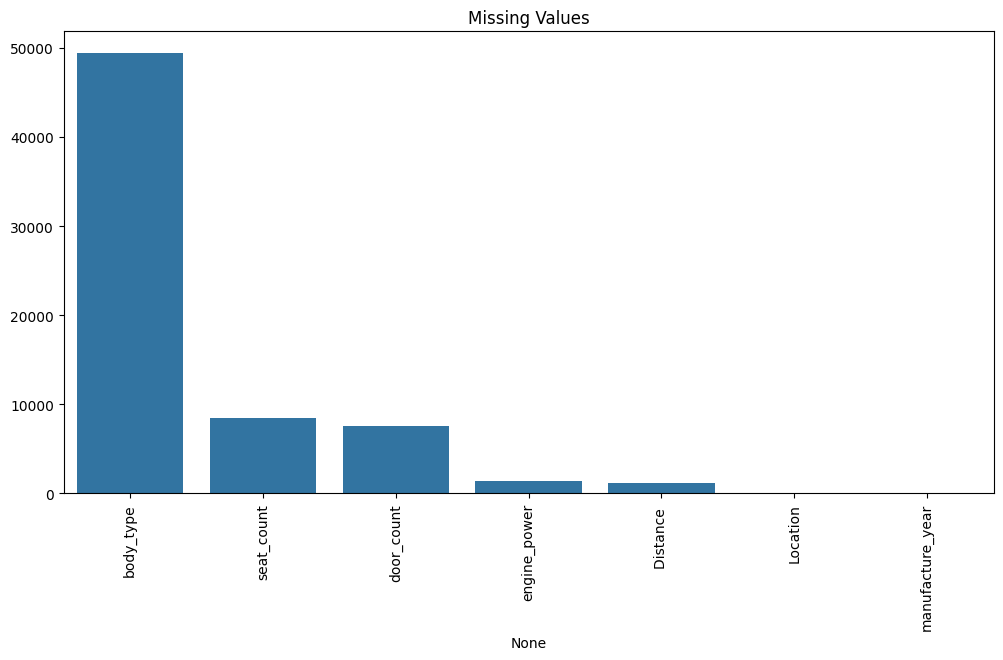

In [134]:
plt.figure(figsize=(12,6))

sns.barplot(
    x=missing.index,
    y=missing.values
)

plt.xticks(rotation=90)

plt.title("Missing Values")

plt.show()

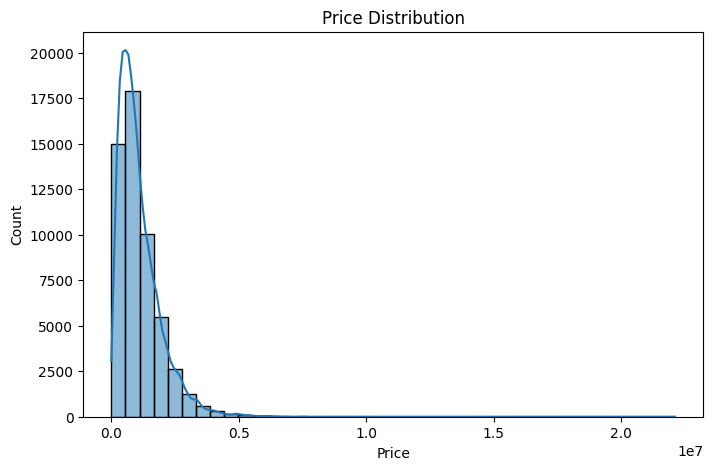

In [135]:
plt.figure(figsize=(8,5))

sns.histplot(train["Price"], bins=40, kde=True)

plt.title("Price Distribution")

plt.show()

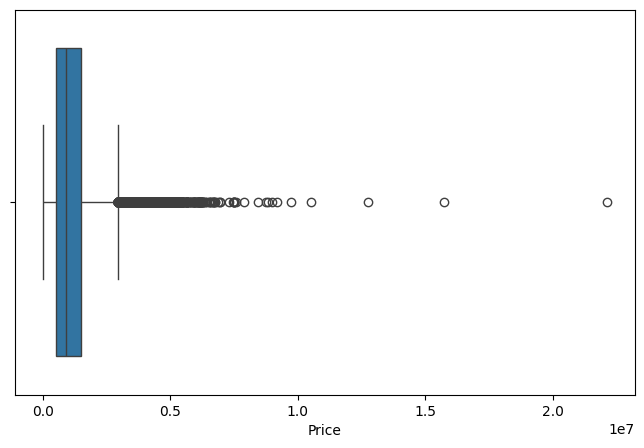

In [136]:
plt.figure(figsize=(8,5))

sns.boxplot(x=train["Price"])

plt.show()

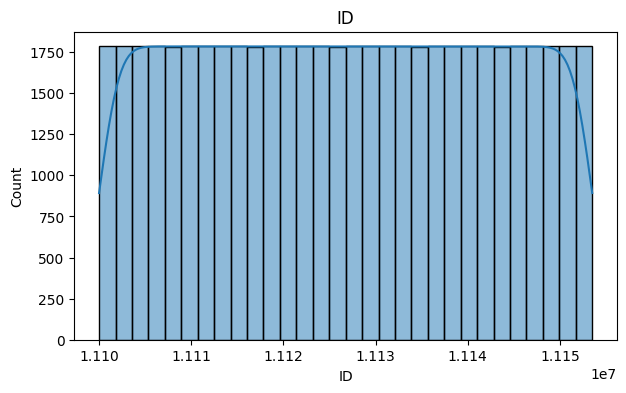

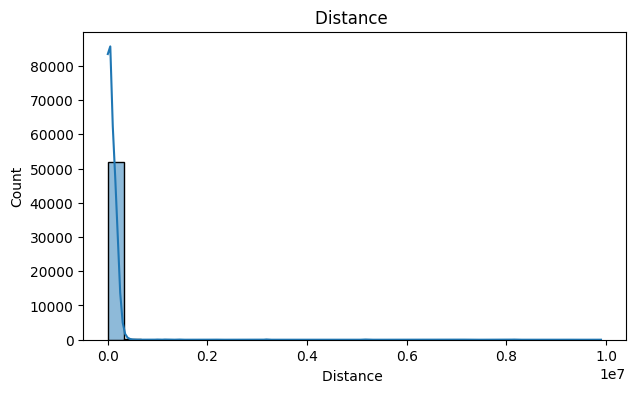

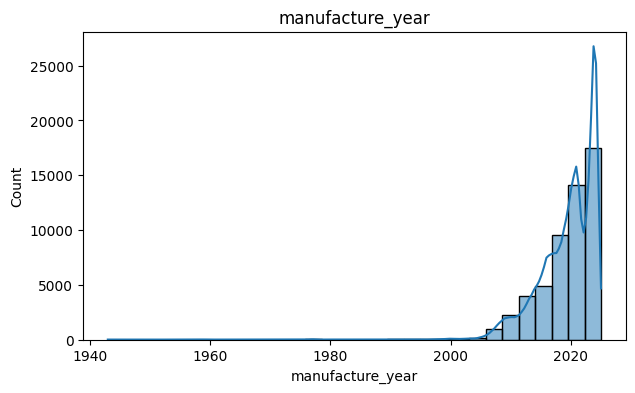

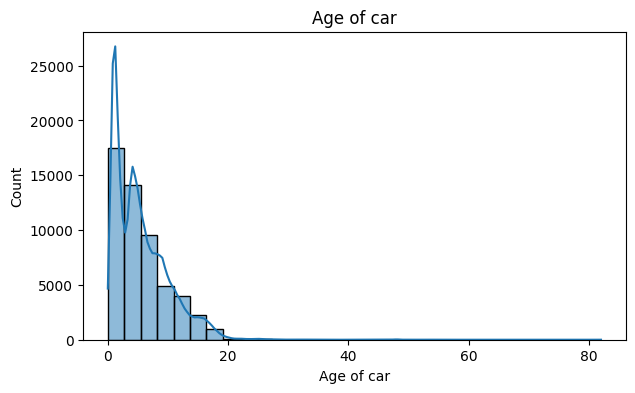

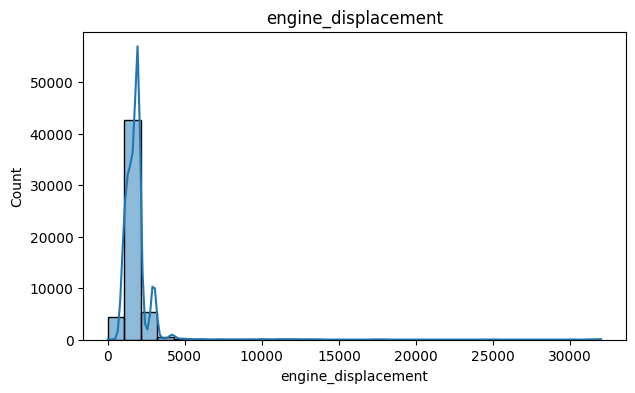

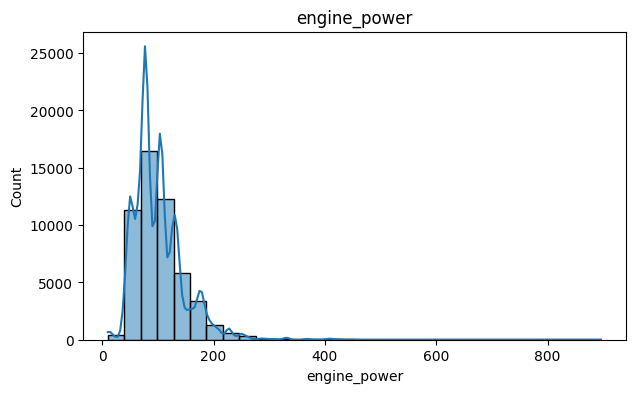

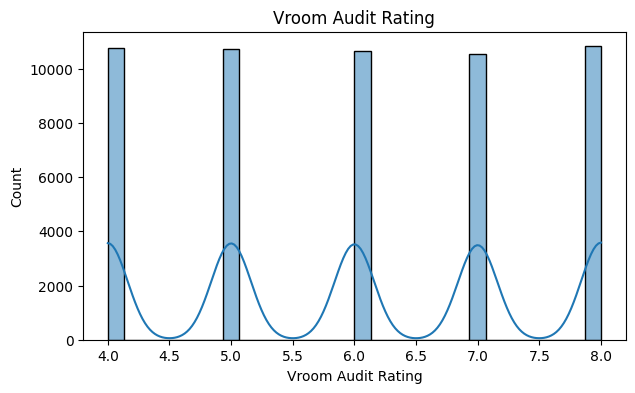

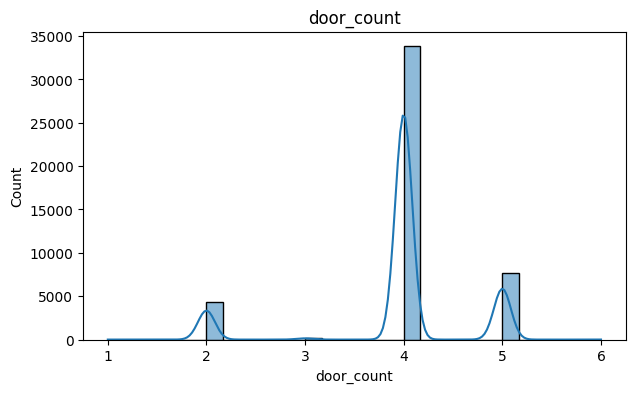

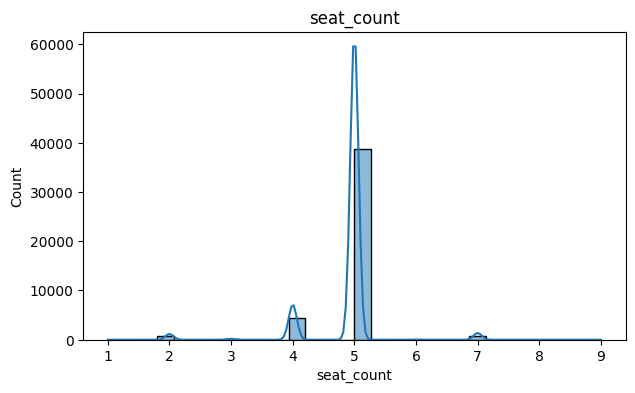

In [137]:
for col in numerical_cols:

    if col == "Price":
        continue

    plt.figure(figsize=(7,4))

    sns.histplot(train[col], bins=30, kde=True)

    plt.title(col)

    plt.show()

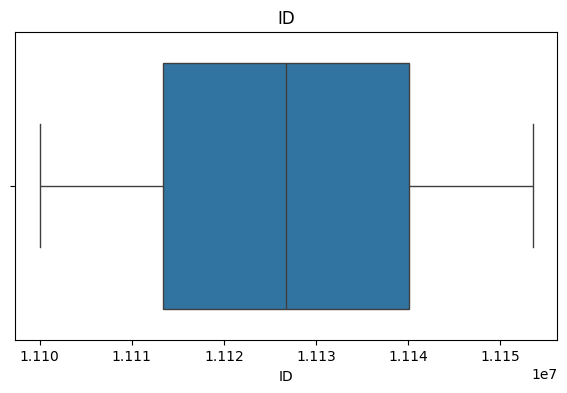

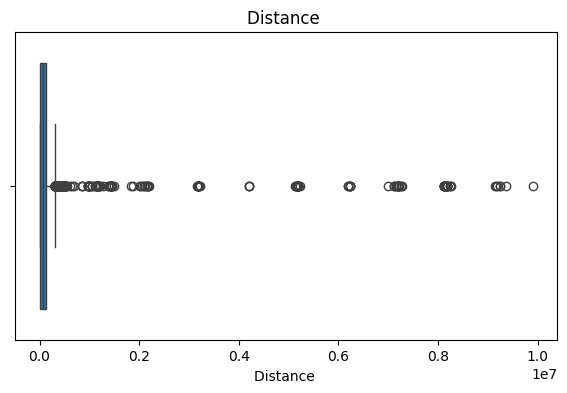

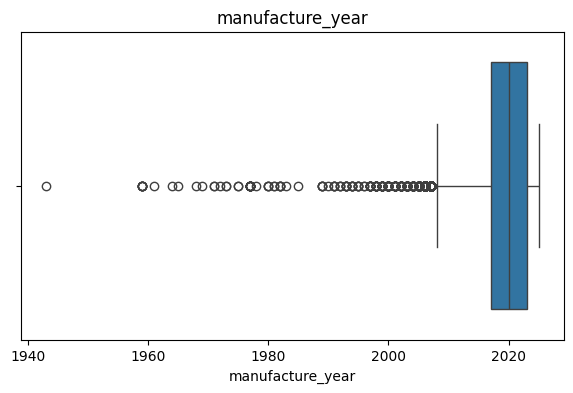

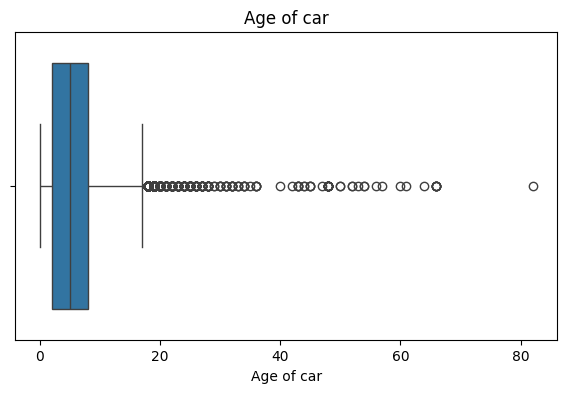

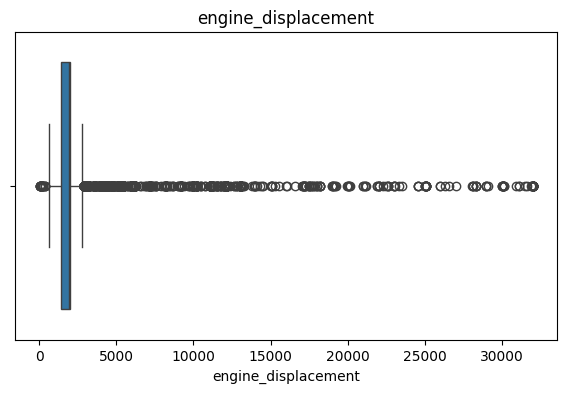

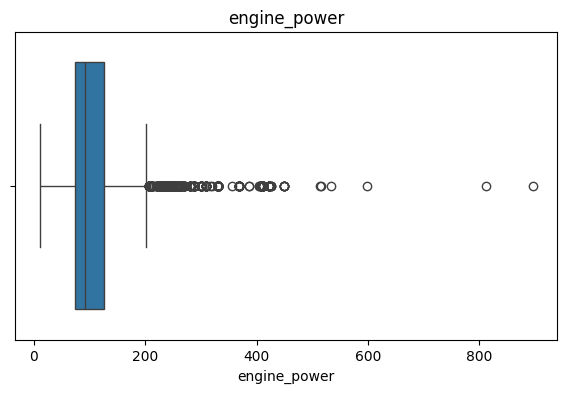

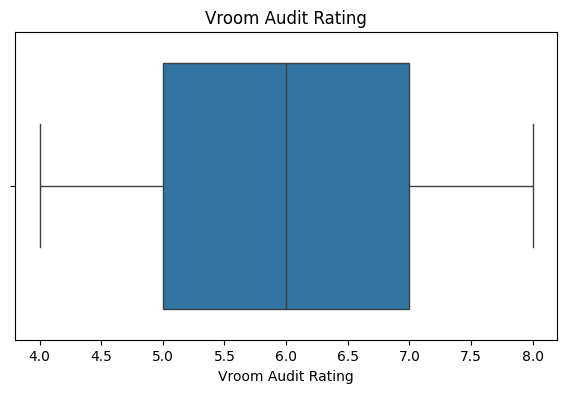

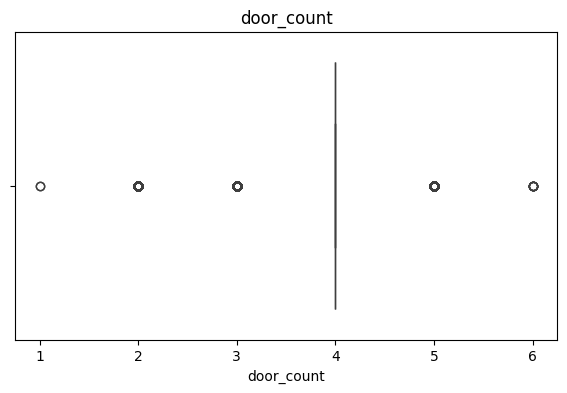

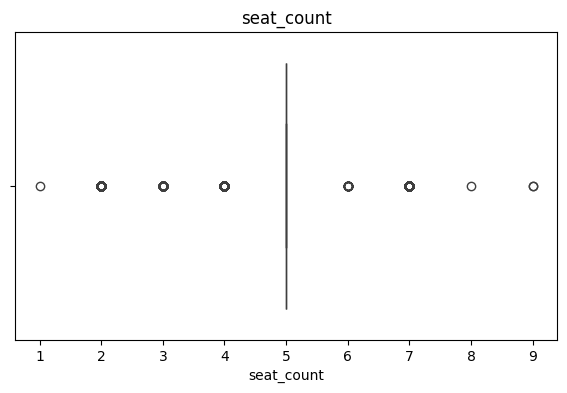

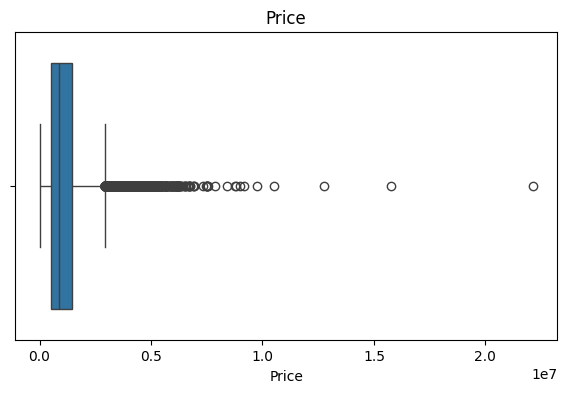

In [138]:
for col in numerical_cols:

    plt.figure(figsize=(7,4))

    sns.boxplot(x=train[col])

    plt.title(col)

    plt.show()

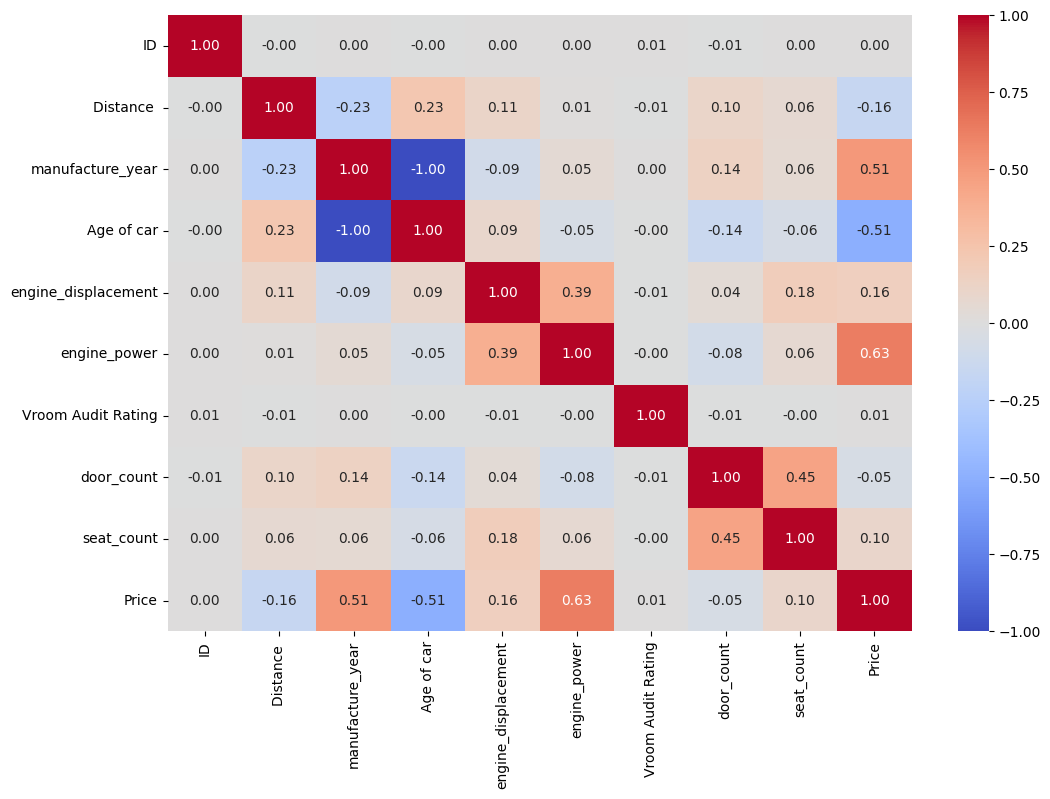

In [139]:
plt.figure(figsize=(12,8))

corr = train[numerical_cols].corr()

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.show()

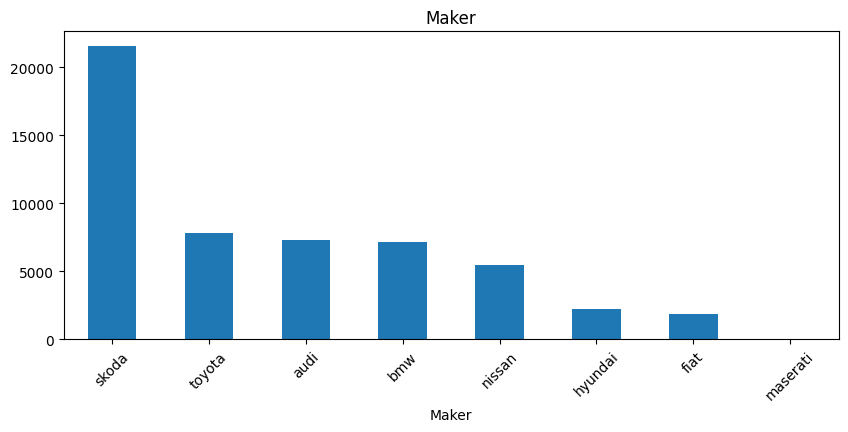

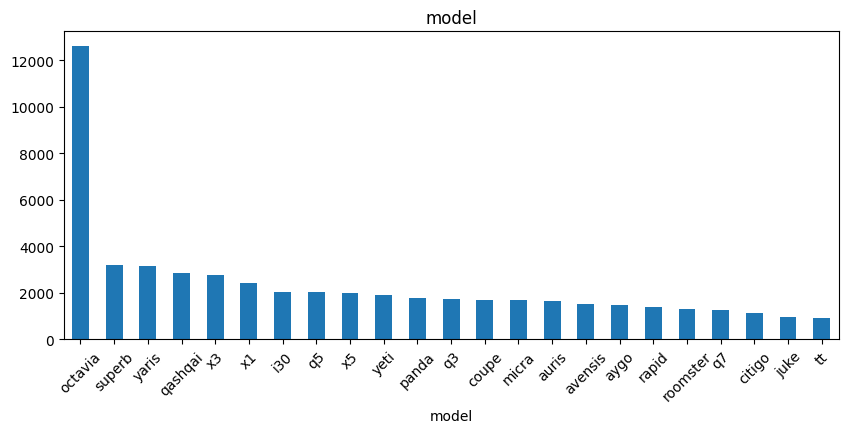

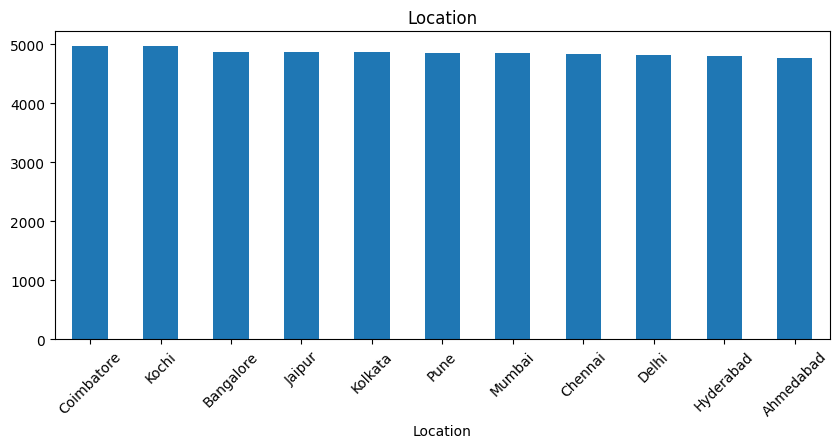

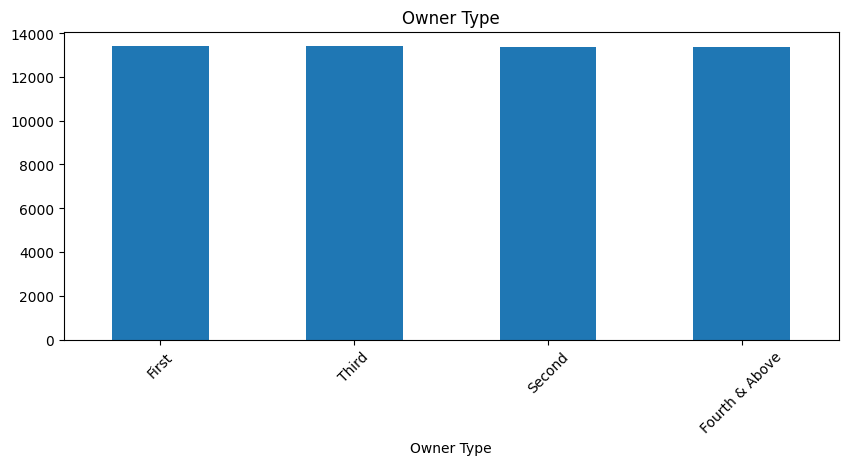

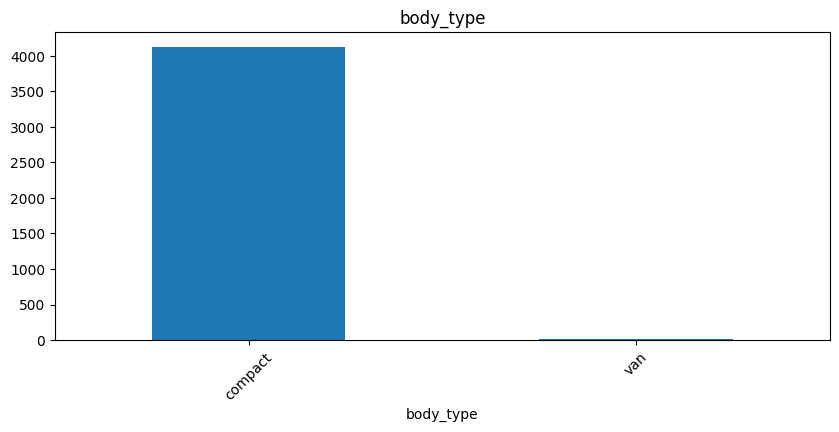

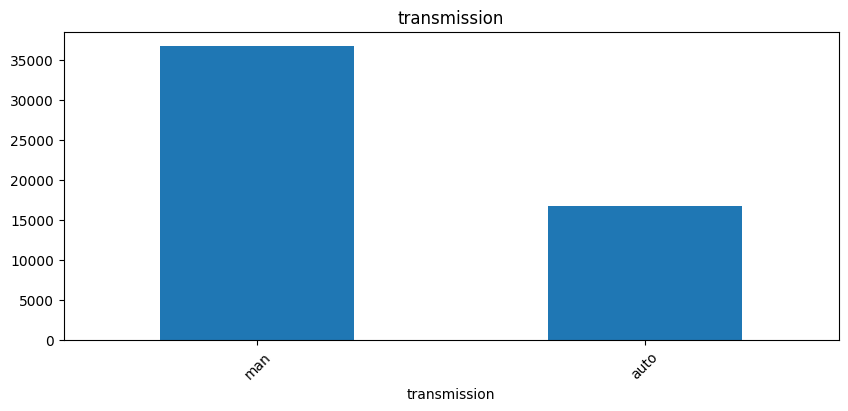

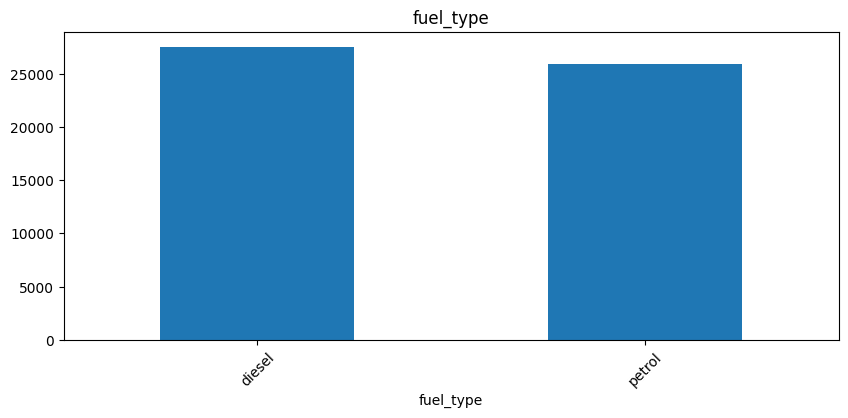

In [140]:
for col in categorical_cols:

    plt.figure(figsize=(10,4))

    train[col].value_counts().plot(kind="bar")

    plt.title(col)

    plt.xticks(rotation=45)

    plt.show()

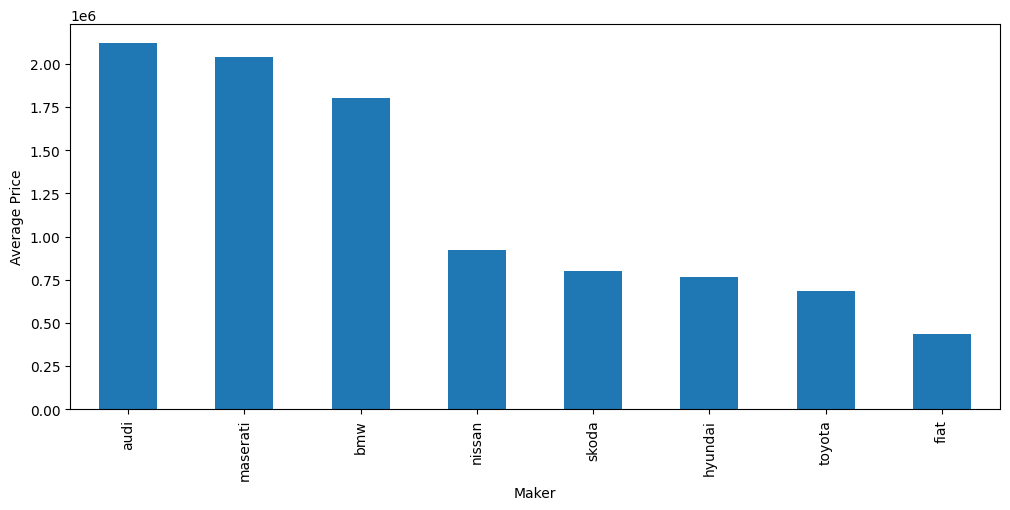

In [141]:
maker_price = train.groupby("Maker")["Price"].mean().sort_values(ascending=False)

plt.figure(figsize=(12,5))

maker_price.plot(kind="bar")

plt.ylabel("Average Price")

plt.show()

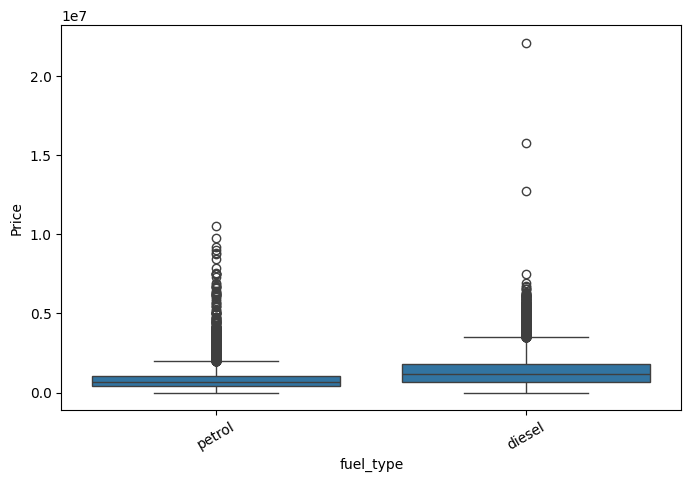

In [142]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x="fuel_type",
    y="Price",
    data=train
)

plt.xticks(rotation=30)

plt.show()

In [143]:
print(train.columns.tolist())
print(train.head())

['ID', 'Maker', 'model', 'Location', 'Distance ', 'Owner Type', 'manufacture_year', 'Age of car', 'engine_displacement', 'engine_power', 'body_type', 'Vroom Audit Rating', 'transmission', 'door_count', 'seat_count', 'fuel_type', 'Price']
         ID   Maker    model   Location  Distance       Owner Type  \
0  11100001   skoda  octavia  Ahmedabad        NaN          Second   
1  11100002    fiat    panda  Ahmedabad    27750.0           Third   
2  11100003     bmw       x1  Hyderabad    46000.0           Third   
3  11100004  nissan     juke     Mumbai    43949.0           Third   
4  11100005     bmw       x5     Jaipur    59524.0  Fourth & Above   

   manufacture_year  Age of car  engine_displacement  engine_power body_type  \
0            1973.0          52                 1964         147.0   compact   
1            2021.0           4                 1242          51.0       NaN   
2            2023.0           2                 1995         105.0       NaN   
3            2020.0  

In [144]:
train.columns = train.columns.str.strip()

print(train.columns.tolist())

['ID', 'Maker', 'model', 'Location', 'Distance', 'Owner Type', 'manufacture_year', 'Age of car', 'engine_displacement', 'engine_power', 'body_type', 'Vroom Audit Rating', 'transmission', 'door_count', 'seat_count', 'fuel_type', 'Price']


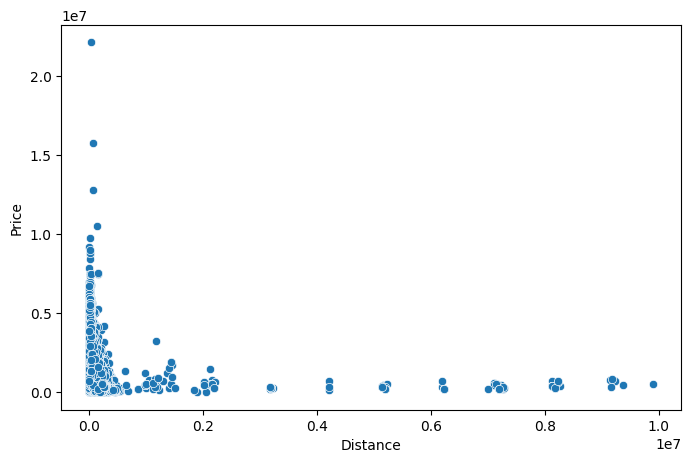

In [145]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    x="Distance",
    y="Price",
    data=train
)

plt.show()

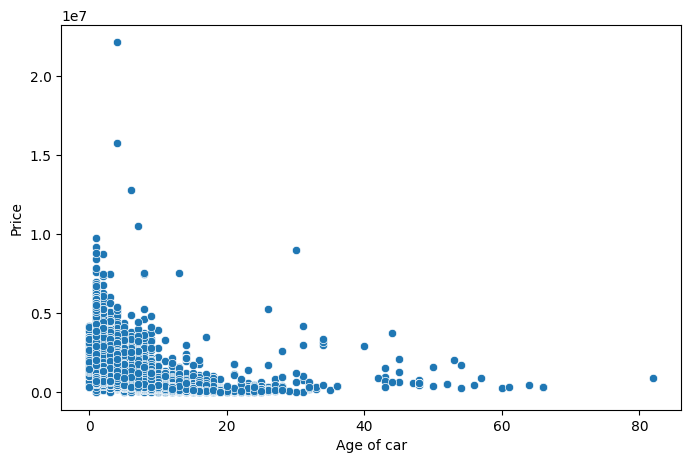

In [146]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    x="Age of car",
    y="Price",
    data=train
)

plt.show()

In [147]:
train.columns

Index(['ID', 'Maker', 'model', 'Location', 'Distance', 'Owner Type',
       'manufacture_year', 'Age of car', 'engine_displacement', 'engine_power',
       'body_type', 'Vroom Audit Rating', 'transmission', 'door_count',
       'seat_count', 'fuel_type', 'Price'],
      dtype='object')

In [148]:
X = train.drop("Price", axis=1)

y = train["Price"]

In [149]:
if "ID" in X.columns:
    X = X.drop("ID", axis=1)
    test = test.drop("ID", axis=1)

In [150]:
current_year = 2025

if "manufacture_year" in X.columns:
    X["Car_Age"] = current_year - X["manufacture_year"]
    test["Car_Age"] = current_year - test["manufacture_year"]

In [151]:
numerical_features = X.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

categorical_features = X.select_dtypes(
    include=["object"]
).columns.tolist()

print(numerical_features)
print(categorical_features)

['Distance', 'manufacture_year', 'Age of car', 'engine_displacement', 'engine_power', 'Vroom Audit Rating', 'door_count', 'seat_count', 'Car_Age']
['Maker', 'model', 'Location', 'Owner Type', 'body_type', 'transmission', 'fuel_type']


In [152]:
numeric_transformer = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="median")
        ),
        (
            "scaler",
            StandardScaler()
        )
    ]
)

In [153]:
categorical_transformer = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="most_frequent")
        ),
        (
            "encoder",
            OneHotEncoder(
                handle_unknown="ignore"
            )
        )
    ]
)

In [154]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            numeric_transformer,
            numerical_features
        ),
        (
            "cat",
            categorical_transformer,
            categorical_features
        )
    ]
)

In [155]:
X_train, X_valid, y_train, y_valid = train_test_split(X, y, test_size=0.2, random_state=42)

In [156]:
print(X_train.shape)
print(X_valid.shape)
print(y_train.shape)
print(y_valid.shape)

(42812, 16)
(10703, 16)
(42812,)
(10703,)


In [157]:
linear_model = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor
        ),
        (
            "model",
            LinearRegression()
        )
    ]
)

In [158]:
linear_model.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [159]:
pred = linear_model.predict(X_valid)

In [160]:
mae = mean_absolute_error(y_valid, pred)

rmse = np.sqrt(mean_squared_error(y_valid, pred))

r2 = r2_score(y_valid, pred)

print("MAE :", mae)
print("RMSE:", rmse)
print("R2 :", r2)

MAE : 263546.23564808385
RMSE: 430756.455942445
R2 : 0.7392719122268552


In [161]:
cv = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

scores = cross_val_score(
    linear_model,
    X,
    y,
    cv=cv,
    scoring="r2"
)

print(scores)
print(scores.mean())

[0.73927192 0.73973615 0.68180678 0.72669882 0.75024713]
0.7275521598388731


In [162]:
def evaluate_model(name, model):
    pipeline = Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            ("model", model)
        ]
    )

    pipeline.fit(X_train, y_train)

    pred = pipeline.predict(X_valid)

    mae = mean_absolute_error(y_valid, pred)
    rmse = np.sqrt(mean_squared_error(y_valid, pred))
    r2 = r2_score(y_valid, pred)

    print("=" * 60)
    print(name)
    print("MAE :", round(mae, 2))
    print("RMSE:", round(rmse, 2))
    print("R2 :", round(r2, 4))

    return pipeline, rmse

In [163]:
linear_pipeline, linear_rmse = evaluate_model(
    "Linear Regression",
    LinearRegression()
)

Linear Regression
MAE : 263546.24
RMSE: 430756.46
R2 : 0.7393


In [164]:
rf_pipeline, rf_rmse = evaluate_model(
    "Random Forest",
    RandomForestRegressor(
        n_estimators=300,
        random_state=42,
        n_jobs=-1
    )
)

Random Forest
MAE : 107622.61
RMSE: 200707.21
R2 : 0.9434


In [165]:
gb_pipeline, gb_rmse = evaluate_model(
    "Gradient Boosting",
    GradientBoostingRegressor(
        random_state=42
    )
)

Gradient Boosting
MAE : 141705.31
RMSE: 227015.31
R2 : 0.9276


In [166]:
xgb_pipeline, xgb_rmse = evaluate_model(
    "XGBoost",
    XGBRegressor(
        n_estimators=500,
        learning_rate=0.05,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        objective="reg:squarederror"
    )
)

XGBoost
MAE : 111570.4
RMSE: 200892.85
R2 : 0.9433


In [167]:
lgb_pipeline, lgb_rmse = evaluate_model(
    "LightGBM",
    LGBMRegressor(
        n_estimators=500,
        learning_rate=0.05,
        random_state=42
    )
)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.002344 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 889
[LightGBM] [Info] Number of data points in the train set: 42812, number of used features: 59
[LightGBM] [Info] Start training from score 1095742.028905
LightGBM
MAE : 112942.82
RMSE: 198689.92
R2 : 0.9445


In [168]:
cat_pipeline, cat_rmse = evaluate_model(
    "CatBoost",
    CatBoostRegressor(
        iterations=500,
        learning_rate=0.05,
        depth=6,
        random_state=42,
        verbose=False
    )
)

CatBoost
MAE : 120107.12
RMSE: 205464.84
R2 : 0.9407


In [169]:
results = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Random Forest",
        "Gradient Boosting",
        "XGBoost",
        "LightGBM",
        "CatBoost"
    ],
    "RMSE": [
        linear_rmse,
        rf_rmse,
        gb_rmse,
        xgb_rmse,
        lgb_rmse,
        cat_rmse
    ]
})

results = results.sort_values("RMSE")

results

,Model,RMSE
4,LightGBM,198689.922838
1,Random Forest,200707.211549
3,XGBoost,200892.853636
5,CatBoost,205464.842703
2,Gradient Boosting,227015.308592
0,Linear Regression,430756.455942


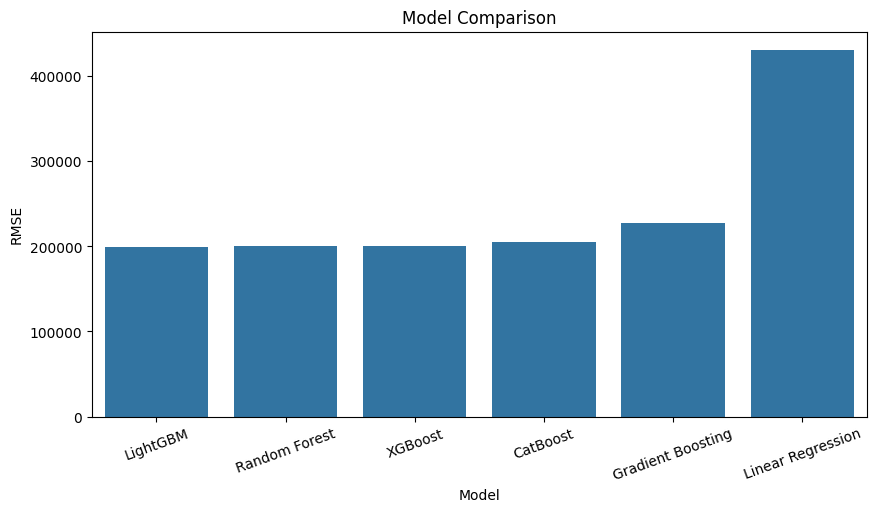

In [170]:
plt.figure(figsize=(10,5))

sns.barplot(
    data=results,
    x="Model",
    y="RMSE"
)

plt.xticks(rotation=20)

plt.title("Model Comparison")

plt.show()

In [171]:
best_pipeline = min(
    [
        ("Linear Regression", linear_pipeline, linear_rmse),
        ("Random Forest", rf_pipeline, rf_rmse),
        ("Gradient Boosting", gb_pipeline, gb_rmse),
        ("XGBoost", xgb_pipeline, xgb_rmse),
        ("LightGBM", lgb_pipeline, lgb_rmse),
        ("CatBoost", cat_pipeline, cat_rmse),
    ],
    key=lambda x: x[2]
)

print("Best Model:", best_pipeline[0])
print("Best RMSE:", best_pipeline[2])

Best Model: LightGBM
Best RMSE: 198689.92283781423


In [172]:
import os

os.makedirs("../models", exist_ok=True)

joblib.dump(best_pipeline[1], "../models/best_model.pkl")

['../models/best_model.pkl']

In [173]:
param_grid = {
    "model__n_estimators": [200, 300, 500, 700],
    "model__max_depth": [3, 5, 7, 9],
    "model__learning_rate": [0.01, 0.03, 0.05, 0.1],
    "model__subsample": [0.7, 0.8, 0.9, 1.0],
    "model__colsample_bytree": [0.7, 0.8, 0.9, 1.0]
}

In [174]:
xgb_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            XGBRegressor(
                random_state=42,
                objective="reg:squarederror"
            )
        )
    ]
)

In [175]:
random_search = RandomizedSearchCV(
    estimator=xgb_pipeline,
    param_distributions=param_grid,
    n_iter=20,
    scoring="neg_root_mean_squared_error",
    cv=5,
    verbose=2,
    random_state=42,
    n_jobs=-1
)

In [176]:
random_search.fit(X_train, y_train)

Fitting 5 folds for each of 20 candidates, totalling 100 fits


,estimator,"Pipeline(step...=None, ...))])"
,param_distributions,"{'model__colsample_bytree': [0.7, 0.8, ...], 'model__learning_rate': [0.01, 0.03, ...], 'model__max_depth': [3, 5, ...], 'model__n_estimators': [200, 300, ...], ...}"
,n_iter,20
,scoring,'neg_root_mean_squared_error'
,n_jobs,-1
,refit,True
,cv,5
,verbose,2
,pre_dispatch,'2*n_jobs'
,random_state,42
,error_score,nan


In [177]:
print(random_search.best_params_)

{'model__subsample': 0.7, 'model__n_estimators': 300, 'model__max_depth': 5, 'model__learning_rate': 0.05, 'model__colsample_bytree': 0.8}


In [178]:
best_model = random_search.best_estimator_

In [179]:
pred = best_model.predict(X_valid)

In [180]:
mae = mean_absolute_error(y_valid, pred)

rmse = np.sqrt(mean_squared_error(y_valid, pred))

r2 = r2_score(y_valid, pred)

print("MAE :", round(mae,2))
print("RMSE:", round(rmse,2))
print("R²  :", round(r2,4))

MAE : 118644.85
RMSE: 201869.0
R²  : 0.9427


In [181]:
cv_scores = cross_val_score(best_model, X, y, cv=5, scoring="r2", n_jobs=-1 )

print(cv_scores)
print(cv_scores.mean())

[0.92543881 0.93823368 0.9538175  0.90374272 0.91938813]
0.928124166614929


In [182]:
model = best_model.named_steps["model"]

In [183]:
feature_names = best_model.named_steps[
    "preprocessor"
].get_feature_names_out()

In [184]:
importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": model.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

In [185]:
importance.head(20)

,Feature,Importance
4,num__engine_power,0.120328
9,cat__Maker_audi,0.114905
1,num__manufacture_year,0.105576
57,cat__transmission_auto,0.100696
10,cat__Maker_bmw,0.064628
2,num__Age of car,0.053389
58,cat__transmission_man,0.049645
3,num__engine_displacement,0.046723
27,cat__model_q3,0.035952
15,cat__Maker_skoda,0.034076


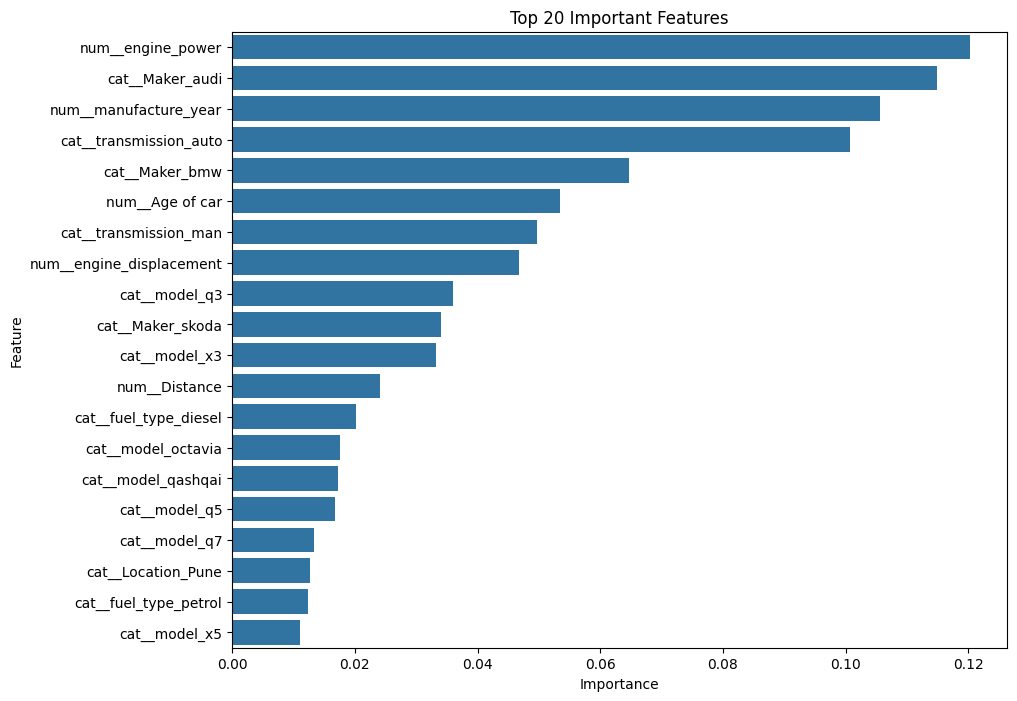

In [186]:
plt.figure(figsize=(10,8))

sns.barplot(
    data=importance.head(20),
    x="Importance",
    y="Feature"
)

plt.title("Top 20 Important Features")

plt.show()

In [187]:
import os

os.makedirs("../models", exist_ok=True)

joblib.dump(best_model, "../models/best_model.pkl")

['../models/best_model.pkl']

In [188]:
joblib.dump(feature_names, "../models/feature_names.pkl")

joblib.dump(
    best_model.named_steps["preprocessor"],
    "../models/preprocessor.pkl"
)

['../models/preprocessor.pkl']

In [189]:
import joblib

best_model = joblib.load("../models/best_model.pkl")

In [190]:
test = pd.read_csv("../data/Cap_Test_Data_2025.csv")
sample = pd.read_csv("../data/Cap_Sample_Submission_2025.csv")

In [191]:
test_ids = test["ID"]

In [192]:
print("Train columns:")
print(X.columns.tolist())

print("\nTest columns:")
print(test_input.columns.tolist())

Train columns:
['Maker', 'model', 'Location', 'Distance', 'Owner Type', 'manufacture_year', 'Age of car', 'engine_displacement', 'engine_power', 'body_type', 'Vroom Audit Rating', 'transmission', 'door_count', 'seat_count', 'fuel_type', 'Car_Age']

Test columns:
['Maker', 'model', 'Location', 'Distance', 'Owner Type', 'manufacture_year', 'Age of car', 'engine_displacement', 'engine_power', 'body_type', 'Vroom Audit Rating', 'transmission', 'door_count', 'seat_count', 'fuel_type', 'Car_Age']


In [193]:
missing = set(X.columns) - set(test_input.columns)
extra = set(test_input.columns) - set(X.columns)

print("Missing columns:", missing)
print("Extra columns:", extra)

Missing columns: set()
Extra columns: set()


In [194]:
test_input = test.copy()

In [195]:
test.columns = test.columns.str.strip()

test_input = test.drop(columns=["ID"])

if "manufacture_year" in test_input.columns:
    test_input["Car_Age"] = 2025 - test_input["manufacture_year"]

predictions = best_model.predict(test_input)

In [196]:
predictions[:10]

array([ 401658.88,  996982.2 , 1503084.4 , 2399130.  , 2851395.8 ,
       2662167.2 , 3220288.5 , 2450257.  ,  344859.84, 1240535.2 ],
      dtype=float32)

In [197]:
submission = pd.DataFrame({
    "ID": test_ids,
    "Price": predictions
})

In [198]:
submission.to_csv("../outputs/submission.csv", index=False)

In [199]:
submission.head()

,ID,Price
0,21100001,4.016589e+05
1,21100002,9.969822e+05
2,21100003,1.503084e+06
3,21100004,2.399130e+06
4,21100005,2.851396e+06


In [200]:
pred = best_model.predict(X_valid)

print("MAE :", mean_absolute_error(y_valid, pred))
print("RMSE:", np.sqrt(mean_squared_error(y_valid, pred)))
print("R²  :", r2_score(y_valid, pred))

MAE : 118644.84582830894
RMSE: 201868.99835776712
R²  : 0.9427383991356667


# Conclusion

- Performed data cleaning and preprocessing.
- Conducted exploratory data analysis (EDA).
- Engineered additional features.
- Trained multiple regression models:
  - Linear Regression
  - Random Forest
  - Gradient Boosting
  - XGBoost
  - LightGBM
  - CatBoost
- Selected the best-performing model using RMSE, MAE, and R².
- Saved the trained model using Joblib.
- Generated predictions for the test dataset.
- Created the final `submission.csv` file.
- The trained model is ready for deployment with Streamlit.